In [23]:
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')
sys.path.append('/scratch/marian/python/notebooks/modules')

from import_modules import *
import cigar as cig

from scipy.optimize import curve_fit
from scipy.signal import find_peaks


##  Data reading

In [24]:
directory   = '/data/marian/cigar/ProcessedWaveforms/'
# directory   = '/scratch/marian/cigar/'

pressure    = 7.5 # bar
temperature = 9 # deg

In [25]:
if (pressure == 'air') & (temperature == 10):
    file_noKr   = '20250818_Air_no_source_10deg_54.35V_Autotrg_DCR_output_1.csv'
if (pressure == 'air') & (temperature == 13):
    file_noKr   = '20250818_Air_no_source_13deg_54.48V_Autotrg_DCR_output_1.csv'
if (pressure == 'air') & (temperature == 16):
    file_noKr   = '20250818_Air_no_source_16deg_54.61V_Autotrg_DCR_output_1.csv'
if (pressure == 'air') & (temperature == 19):
    file_noKr   = '20250818_Air_no_source_19deg_54.74V_Autotrg_DCR_output_1.csv'
if (pressure == 'air') & (temperature == 22):
    file_noKr   = '20250818_Air_no_source_22deg_54.87V_Autotrg_DCR_output_1.csv'
if (pressure == 'air') & (temperature == 25):
    file_noKr   = '20250818_Air_no_source_25deg_55V_Autotrg_DCR_output_1.csv'

if (pressure == 8.5) & (temperature == 2):
    run_noKr    = '20250606_no_source_8.5bar_ArXe_2deg/'
    file_noKr   = '20250606_ArXe_8.5bar_no_source_2deg_Autotrg_output_1.csv'
if (pressure == 7.5) & (temperature == 9):
    run_noKr    = '20250612_no_source_7.5bar_ArXe_9deg/'
    file_noKr   = '20250612_ArXe_7.5bar_no_source_9deg_Autotrg_output_1.csv'
if (pressure == 6.5) & (temperature == 4):
    run_noKr    = '20250610_no_source_6.5bar_ArXe_4deg/'
    file_noKr   = '20250610_ArXe_6.5bar_no_source_4deg_Autotrg_output_1.csv'
if (pressure == 5.5) & (temperature == -1):
    # run_noKr    = '20250613_ArXe_5.5bar_Kr_-1deg_Autotrg/'
    run_noKr    = 'outputs/'
    file_noKr   = '20250613_ArXe_5.5bar_no_source_-1deg_Autotrg_output_1.csv'

In [26]:
if (pressure == 'air'):
    df_noKr = pd.read_csv('/scratch/marian/cigar/outputs/' + file_noKr)
else:
    df_noKr = pd.read_csv(directory + run_noKr + file_noKr)


##  Data Fit: Finger Plot

In [ ]:
def FingerPlot(n_gaussians):

    opt_A, opt_mu, opt_sigma, opt_mu_errors = {}, {}, {}, {}

    for ch in [1, 2, 3, 4]:
    # for ch in [4]:
    
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 7), constrained_layout=True)

        if ch == 1:
            num_gaussians = 6
        else:
            num_gaussians = n_gaussians
        
        font_size = 20

        events, bins, image = ax.hist(df_noKr.groupby('channel').get_group(f'CH{ch}').integral 
                                    ,bins = 600 
                                    ,range = (0., 1e-6)
                                    ,density = False
                                    ,alpha = 0.5
                                    ,label = f'channel {ch} noKr'
                                    )

        # Find peaks
        peaks, _ = find_peaks(events, distance=25, prominence = 0.3, width = (bins[1] - bins[0])/4)

        bins_means = (bins[:-1] + bins[1:])/2

        if ch in [0]:
            msk = (bins_means > (bins_means[peaks][0] + bins_means[0])*0.55) & (bins_means < bins_means[peaks[num_gaussians]]*0.9)
        else:
            msk = (bins_means > (bins_means[peaks][0] + bins_means[0])*0.4) & (bins_means < bins_means[peaks[num_gaussians]]*0.9)

        x = bins_means[msk]
        y = events[msk]

        initial_guess_A     = list(events[peaks][:num_gaussians]*1e-8)
        initial_guess_mu    = list(bins_means[peaks][:num_gaussians])
        initial_guess_sigma = list(np.diff(bins_means[peaks])[:num_gaussians]/3)
        if ch == 1:
            initial_guess_sigma = list(np.diff(bins_means[peaks])[:num_gaussians]/4)


        ax.plot(initial_guess_mu, events[peaks][:num_gaussians], 'or', alpha = 0.3, markersize = 10)

        # Initial guesses for the parameters
        initial_guess = initial_guess_A + initial_guess_mu + initial_guess_sigma
        # print('initial_guess = ', initial_guess)

        gaussian_sum = cig.sum_of_gaussians(x, *initial_guess)
        gaussian_label = 'Guess: '
        for i, mu in enumerate(initial_guess_mu):
            gaussian_label += fr" $\mu_{i+1}$ = {mu:.2E} "
        gaussian_label += r' [V $\cdot$ s]'

        # ax.plot(x, gaussian_sum, '--', label = gaussian_label)


        # Perform the fit with bounds to keep parameters positive
        bounds = (0, 2e5)  # All parameters must be > 0

        # Perform the fit
        params, covariance = curve_fit(cig.sum_of_gaussians, x, y, p0=initial_guess, maxfev=100000)

        for j in range(10):
            # Fit the model to the data
            lower = np.minimum(params * 0.8, params * 1.2)
            upper = np.maximum(params * 0.8, params * 1.2)
            bounds = (lower, upper)
            if any(bounds[0] - bounds[1] > 0):
                print(j)
                print(params*0.8 - params*1.2)
            params, covariance = curve_fit(cig.sum_of_gaussians, x, y, p0=params, bounds = bounds, maxfev=100000)
         

        # Extract the optimized parameters
        # Extract optimized parameters (split them into A, mu, sigma)
        opt_A[f'CH{ch}'] = params[:num_gaussians]
        opt_mu[f'CH{ch}'] = params[num_gaussians:2*num_gaussians]
        opt_sigma[f'CH{ch}'] = params[2*num_gaussians:]
        # Extract errors (standard deviations) for each mu
        opt_mu_errors[f'CH{ch}'] = np.sqrt(np.diag(covariance)[num_gaussians:2*num_gaussians])


        gaussian_sum = cig.sum_of_gaussians(x, *params)
        ax.plot(x, gaussian_sum, label = 'Gaussian Fit')
        markers = ['*', 'D', 'X', 'o', 'P', '^', 's']
        for i, mu in enumerate(opt_mu[f'CH{ch}'][:-1]):
            ax.plot(mu, cig.sum_of_gaussians(mu, *params), markers[i], label = fr" $\mu_{i+1}$ = {mu:.2E} [V $\cdot$ s]", markersize = 8)

        ax.set_xlabel(r'Integral [V$\cdot$s]', fontsize = font_size);
        ax.set_ylabel(r'Counts', fontsize = font_size);

        ax.set_title(f'{file_noKr}', fontsize = 0.9*font_size)
        
        ax.set_xlim(-.01e-6, 1e-6)
        # ax.set_ylim(0, 2e4)

        ax.set_yscale('log')
        ax.legend(loc = 'best', fontsize = 0.5*font_size)


    return opt_A, opt_mu, opt_sigma, opt_mu_errors

In [40]:
# opt_A

In [41]:
# opt_mu

In [42]:
# opt_sigma

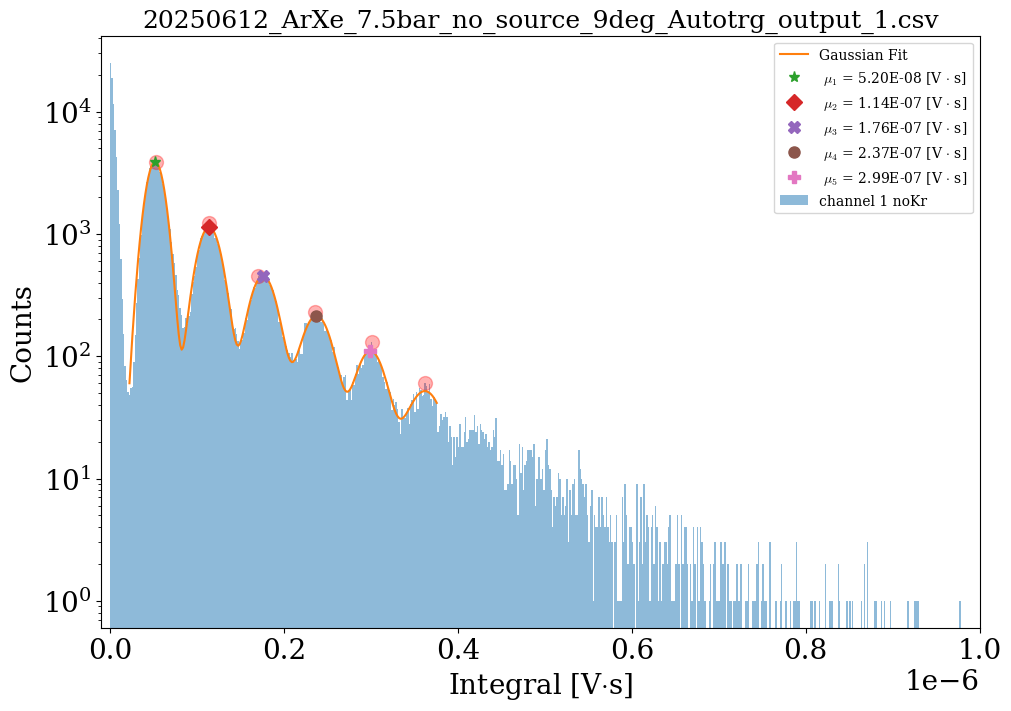

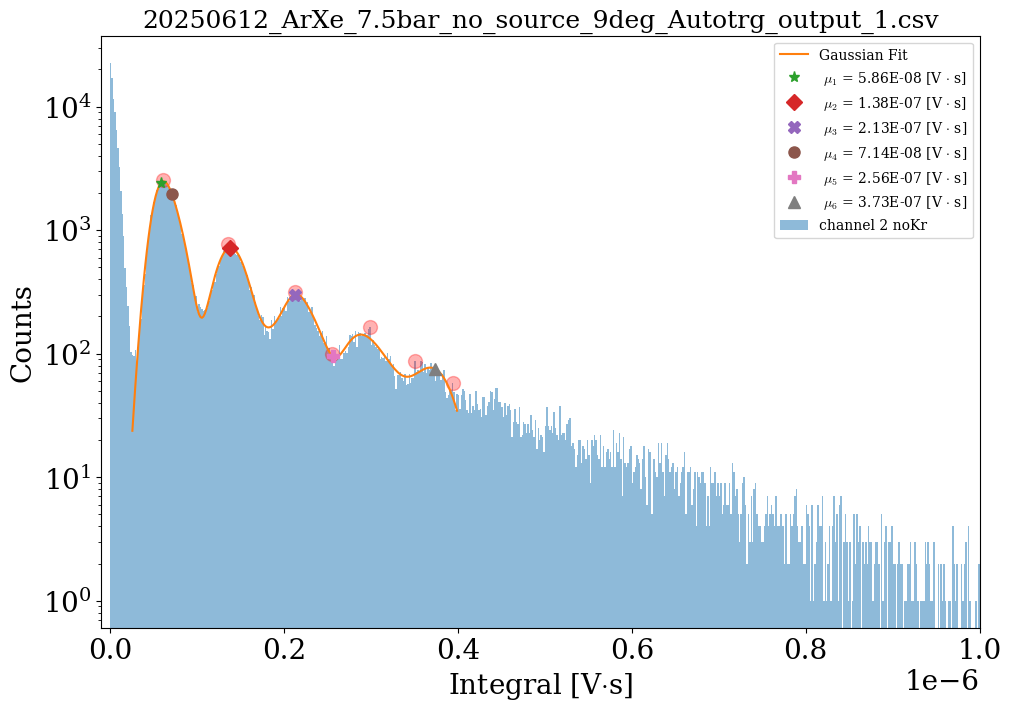

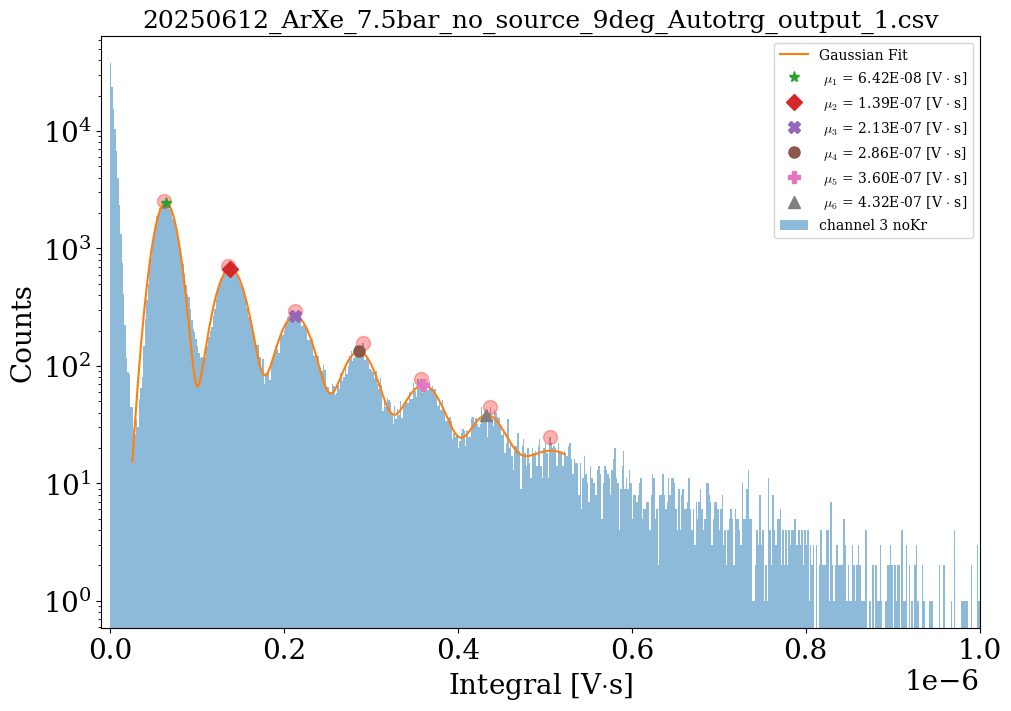

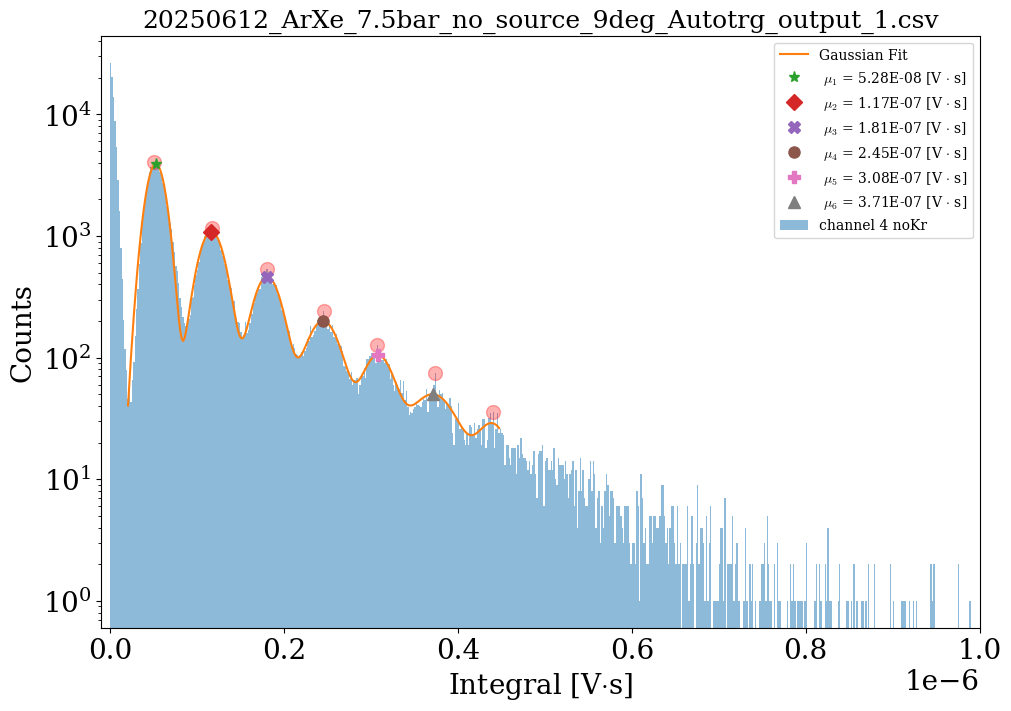

In [43]:
# opt_A, opt_mu, opt_sigma, opt_mu_errors =  FingerPlot(A0, mu0, sigma0)
num_gaussians = 7
opt_A, opt_mu, opt_sigma, opt_mu_errors =  FingerPlot(num_gaussians)


##  Data Analysis: Linearity

In [44]:
opt_mu

{'CH1': array([5.20129906e-08, 1.14094440e-07, 1.75960571e-07, 2.37479514e-07,
        2.99463189e-07, 3.62239870e-07]),
 'CH2': array([5.85508834e-08, 1.38125338e-07, 2.12938004e-07, 7.13890248e-08,
        2.56032254e-07, 3.73257652e-07, 2.40852214e-07]),
 'CH3': array([6.42265708e-08, 1.38644529e-07, 2.12768694e-07, 2.86056163e-07,
        3.60228914e-07, 4.32296215e-07, 5.07351657e-07]),
 'CH4': array([5.27675700e-08, 1.16706460e-07, 1.80781109e-07, 2.44931510e-07,
        3.07712672e-07, 3.71221441e-07, 4.41073714e-07])}

In [45]:
pes_spectrum = opt_mu
err_spectrum = opt_mu_errors

In [46]:
npeaks = -1 # all except last one


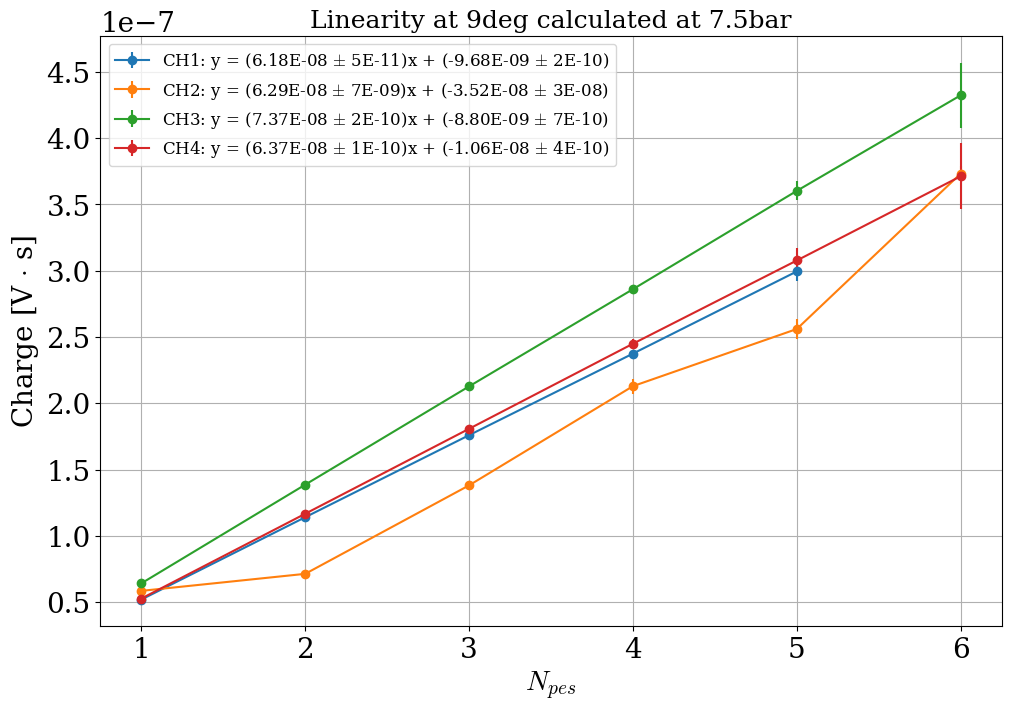

In [47]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,7), constrained_layout=True)

font_size = 20

for ch in pes_spectrum.keys():
# for ch in ['CH3']:

    x = np.arange(len(pes_spectrum[ch][:npeaks])) + 1
    y = pes_spectrum[ch][:npeaks]
    order = np.argsort(y)
    y = y[order]

    # Perform linear fit and get covariance matrix
    params, cov = np.polyfit(x, y, 1, cov=True)
    slope, intercept = params

    # Get errors (standard deviations) from the covariance matrix
    slope_err = np.sqrt(cov[0, 0])
    intercept_err = np.sqrt(cov[1, 1])
    
    ax.errorbar(x, y, yerr = err_spectrum[ch][:npeaks][order],  fmt = 'o-', 
                label = fr'{ch}: y = ({slope:.2E} $\pm$ {slope_err:.0E})x + ({intercept:.2E} $\pm$ {intercept_err:.0E})')
    
    # ax.plot(x, slope*x + intercept, '--', label = f'{ch} fit')


ax.set_title(f'Linearity at {temperature}deg calculated at {pressure}bar', fontsize = 0.9*font_size);
ax.set_xlabel(r'$N_{pes}$', fontsize = font_size);
ax.set_ylabel(r'Charge [V $\cdot$ s]', fontsize = font_size);
ax.grid(True)

ax.legend(fontsize = font_size*0.6)